# ------------ Churn Predictor -------------

# Problem Understanding

Customer churn refers to the situation where a customer stops using a company's service.

In this project, our goal is to build a machine learning model that can predict whether a customer will churn or not.

This is a **Supervised Learning Classification Problem** because:

* We have labeled data
* The target variable (Churn) has two classes: Yes or No

By predicting churn early, companies can take actions to retain customers.


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import OneHotEncoder
print("All important libraries are imported successfully")

All important libraries are imported successfully


# Data Loading

In this step we load the dataset into a pandas DataFrame.

After loading the dataset we check:

* First few rows of data
* Dataset shape
* Column names
* Data types

This helps us understand how the dataset looks before performing analysis.


In [59]:
df = pd.read_csv('customer_churn.csv')
print("Data is loaded successfully")

Data is loaded successfully


In [60]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset Understanding

In this step we explore the dataset to understand its structure.

The dataset contains customer related information such as:

* Gender
* Tenure
* Internet Service
* Contract Type
* Monthly Charges
* Payment Method

The most important column is:

**Churn → Target Variable**

This column tells us whether the customer left the service or not.


In [61]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Visualization

Visualization helps us understand relationships between features and churn.

Some common visualizations used in churn analysis include:

* Churn distribution
* Contract vs Churn
* Internet Service vs Churn
* Monthly Charges distribution

These visualizations help identify patterns and potential factors affecting customer churn.


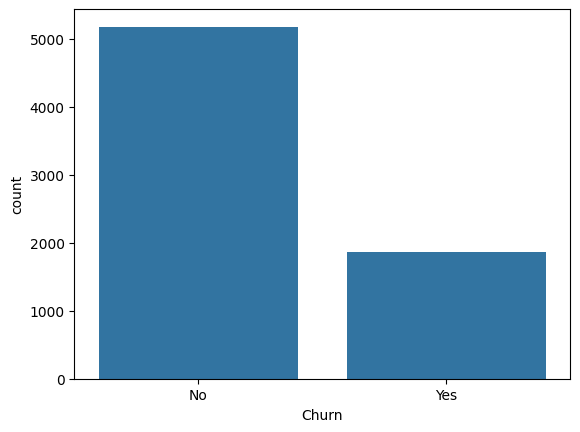

In [62]:
sns.countplot(x='Churn', data=df)
plt.show()

According to the count of churn yes vs no. In this dataset No has maximum value and yes has less value. so our data is embalanced this is very bad for the ml model.

In [63]:
X = df.drop('Churn', axis=1)
y =  df['Churn']

df2 = pd.DataFrame(y)
df2.head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


In [64]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [65]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [66]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In our dataset has total 1869 customer who did churn with company. We use value_counts() function to find labled counting in the column of dataset.

In [67]:
df.drop('customerID', axis=1, inplace=True )

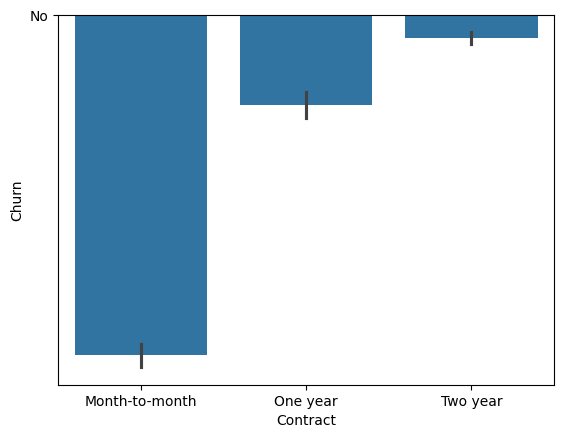

In [68]:
# Contact vs churn
sns.barplot(x='Contract', y='Churn', data=df)
plt.show()

By this Long term contract based customer not churned. and short term contract based customer has churned with company.

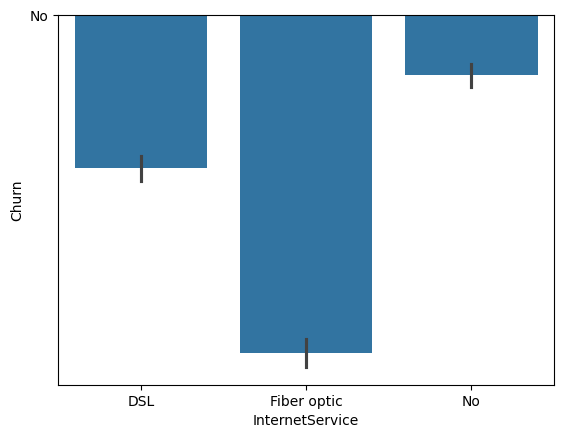

In [69]:
# Internet Service vs Churn

sns.barplot(x='InternetService', y='Churn', data=df)
plt.show()


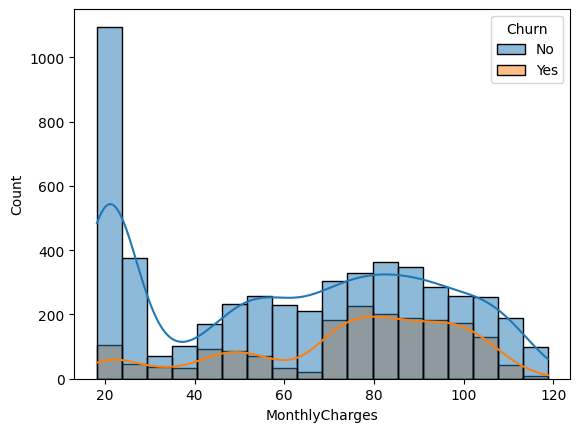

In [70]:
# Monthly Charges vs Churn
sns.histplot(x='MonthlyCharges', hue='Churn', data=df, kde=True)
plt.show()

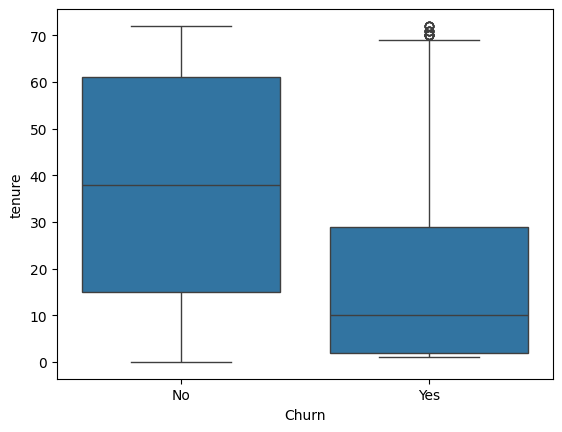

In [71]:
# Tenure vs Churn 
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

# Feature Encoding

Machine learning models cannot understand text values directly.

Therefore categorical variables must be converted into numerical form.

Two common techniques used:

1. **Label Encoding**
   Used for binary categories like Yes/No.

2. **One Hot Encoding**
   Used when a column contains multiple categories.

After encoding, all features become numerical and suitable for machine learning algorithms.


In [73]:
le = LabelEncoder()
on = OneHotEncoder()
for col in df.columns:
    if col in ['gender', 'Partner', 'Dependents', 'PhoneService',  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']:
        df[col] = le.fit_transform(df[col])
    elif col in ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines']:
        df = pd.get_dummies(df, columns=[col])
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,2,0,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,2,0,2,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,2,2,0,0,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,2,0,2,2,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False


In [84]:
# Fill NaN with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [74]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [85]:
# Feature (Input variable)
X = df.drop('Churn', axis=1)

# Target Variable (Output Variable)
y = df['Churn']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(5634, 28) (1409, 28)
(5634,) (1409,)


# Data Cleaning

Real-world datasets often contain inconsistencies and unwanted columns.

In this step we clean the dataset by:

* Removing unnecessary columns such as CustomerID
* Handling missing values if present
* Converting columns into appropriate data types

Data cleaning ensures the dataset is ready for machine learning.


In [86]:
df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
Contract_M

# Step 9: Model Training (Logistic Regression)

In this step we train our Machine Learning model.

Since Customer Churn prediction is a **classification problem** (Yes / No),
we use **Logistic Regression**.

Logistic Regression is a supervised learning algorithm used for binary classification.

### Why Logistic Regression?

1. Simple and fast model
2. Works well for binary classification problems
3. Easy to interpret
4. Good baseline model

### What happens in this step?

The model learns patterns from the **training data** and tries to understand
how input features affect the target variable (Churn).

In [87]:
# Create the model
model = LogisticRegression()
# Train the model
model.fit(X_train, y_train)

c:\Users\shekh\OneDrive\Documents\python_study\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul